In [55]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Download latest version
path = kagglehub.dataset_download("youssefelebiary/google-stock-prices-2015-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\admin\.cache\kagglehub\datasets\youssefelebiary\google-stock-prices-2015-2024\versions\1


In [56]:
df = pd.read_csv(os.path.join(path, 'GoogleStockPrices.csv'))

In [76]:
print(df.shape)
df.head()

(2516, 9)


,Date,Open,High,Low,Close,Volume,Year,Month,Day
0,2015-01-02,26.63,26.79,26.39,26.48,1327870,2015,January,Friday
1,2015-01-05,26.36,26.40,25.89,25.97,2059119,2015,January,Monday
2,2015-01-06,26.02,26.06,25.28,25.33,2731813,2015,January,Tuesday
3,2015-01-07,25.55,25.57,25.18,25.26,2345875,2015,January,Wednesday
4,2015-01-08,25.08,25.38,24.75,25.35,3662224,2015,January,Thursday


In [58]:
df['Date'] = df['Date'].str.split(' ').str[0]

In [59]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2516 non-null   datetime64[ns]
 1   Open    2516 non-null   float64       
 2   High    2516 non-null   float64       
 3   Low     2516 non-null   float64       
 4   Close   2516 non-null   float64       
 5   Volume  2516 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.1 KB


In [61]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-01-02,26.63,26.79,26.39,26.48,1327870
1,2015-01-05,26.36,26.40,25.89,25.97,2059119
2,2015-01-06,26.02,26.06,25.28,25.33,2731813
3,2015-01-07,25.55,25.57,25.18,25.26,2345875
4,2015-01-08,25.08,25.38,24.75,25.35,3662224


In [64]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

In [65]:
df.head()

,Date,Open,High,Low,Close,Volume,Year,Month,Day
0,2015-01-02,26.63,26.79,26.39,26.48,1327870,2015,January,Friday
1,2015-01-05,26.36,26.40,25.89,25.97,2059119,2015,January,Monday
2,2015-01-06,26.02,26.06,25.28,25.33,2731813,2015,January,Tuesday
3,2015-01-07,25.55,25.57,25.18,25.26,2345875,2015,January,Wednesday
4,2015-01-08,25.08,25.38,24.75,25.35,3662224,2015,January,Thursday


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [77]:
df_new = df.copy()

In [78]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Year', 'Month',
       'Day'],
      dtype='object')

(array([16436., 16495., 16556., 16617., 16679., 16740., 16801.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16495.0, 0, '2015-03'),
  Text(16556.0, 0, '2015-05'),
  Text(16617.0, 0, '2015-07'),
  Text(16679.0, 0, '2015-09'),
  Text(16740.0, 0, '2015-11'),
  Text(16801.0, 0, '2016-01')])

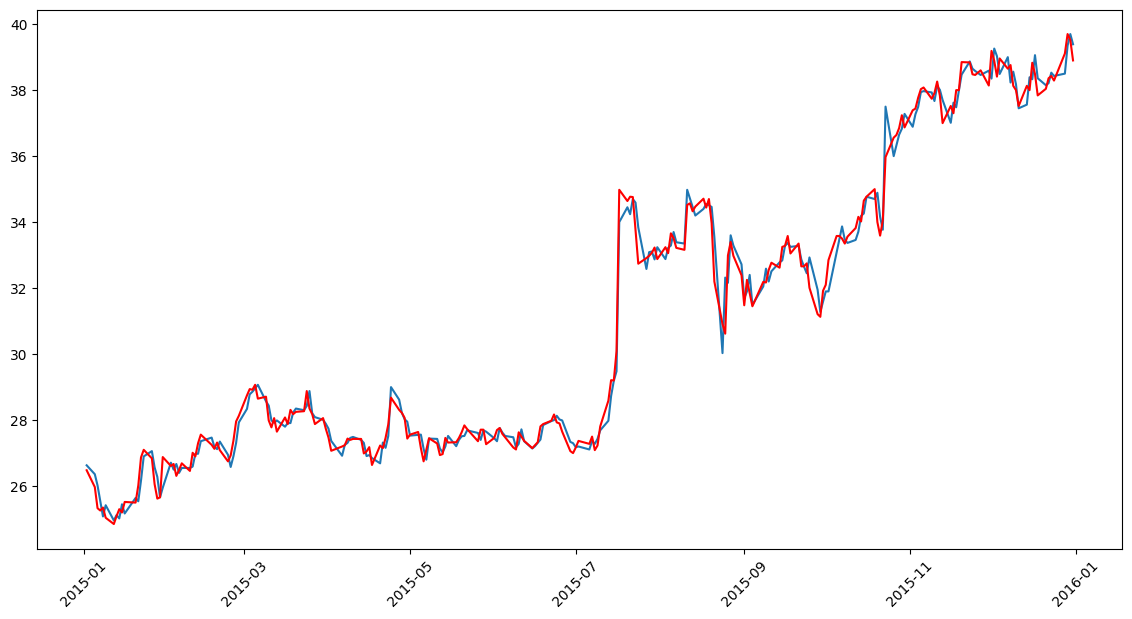

In [87]:
### Here for months in 2015
plt.figure(figsize=(14, 7))
plt.plot(df_new[df_new['Year'] == 2015]['Date'],
         df_new[df_new['Year'] == 2015]['Open'], label='Open')
plt.plot(df_new[df_new['Year'] == 2015]['Date'],
         df_new[df_new['Year'] == 2015]['Close'], label='Close', color='red')
plt.xticks(rotation=45)

(array([16436., 16495., 16556., 16617., 16679., 16740., 16801.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16495.0, 0, '2015-03'),
  Text(16556.0, 0, '2015-05'),
  Text(16617.0, 0, '2015-07'),
  Text(16679.0, 0, '2015-09'),
  Text(16740.0, 0, '2015-11'),
  Text(16801.0, 0, '2016-01')])

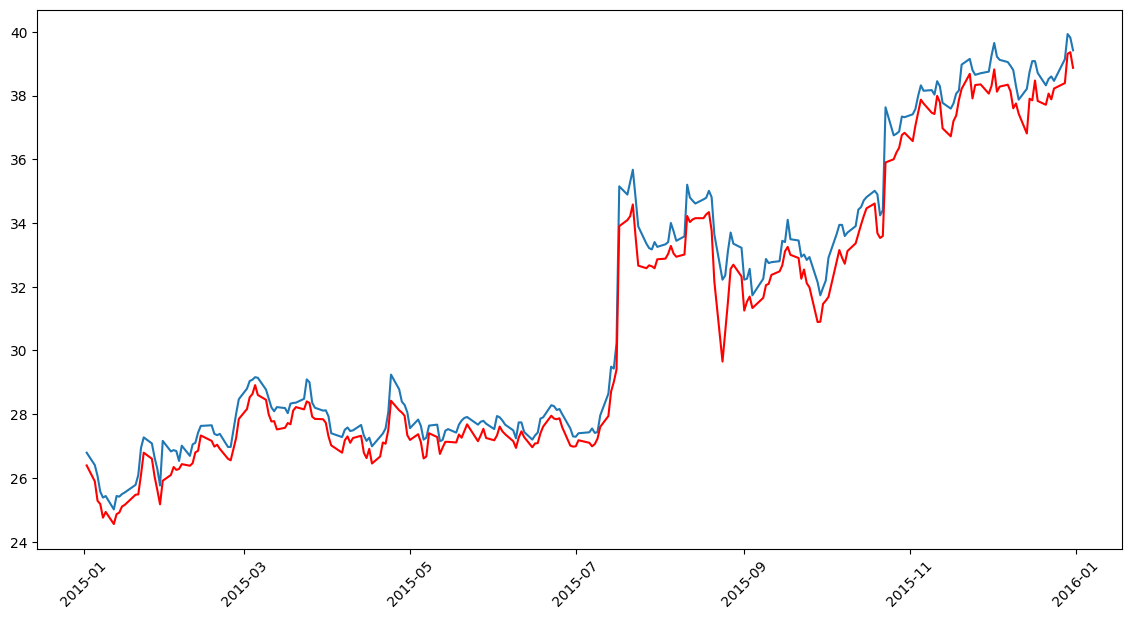

In [93]:
plt.figure(figsize=(14, 7))
plt.plot(df_new[df_new['Year'] == 2015]['Date'],
         df_new[df_new['Year'] == 2015]['High'], label='Open')
plt.plot(df_new[df_new['Year'] == 2015]['Date'],
         df_new[df_new['Year'] == 2015]['Low'], label='Close', color='red')
plt.xticks(rotation=45)

In [94]:
df.tail()

,Date,Open,High,Low,Close,Volume,Year,Month,Day
2511,2024-12-24,194.84,196.11,193.78,196.11,10403259,2024,December,Tuesday
2512,2024-12-26,195.15,196.75,194.38,195.60,12057210,2024,December,Thursday
2513,2024-12-27,194.95,195.32,190.65,192.76,18891362,2024,December,Friday
2514,2024-12-30,189.80,192.55,189.12,191.24,14264659,2024,December,Monday
2515,2024-12-31,191.08,191.96,188.51,189.30,17466919,2024,December,Tuesday


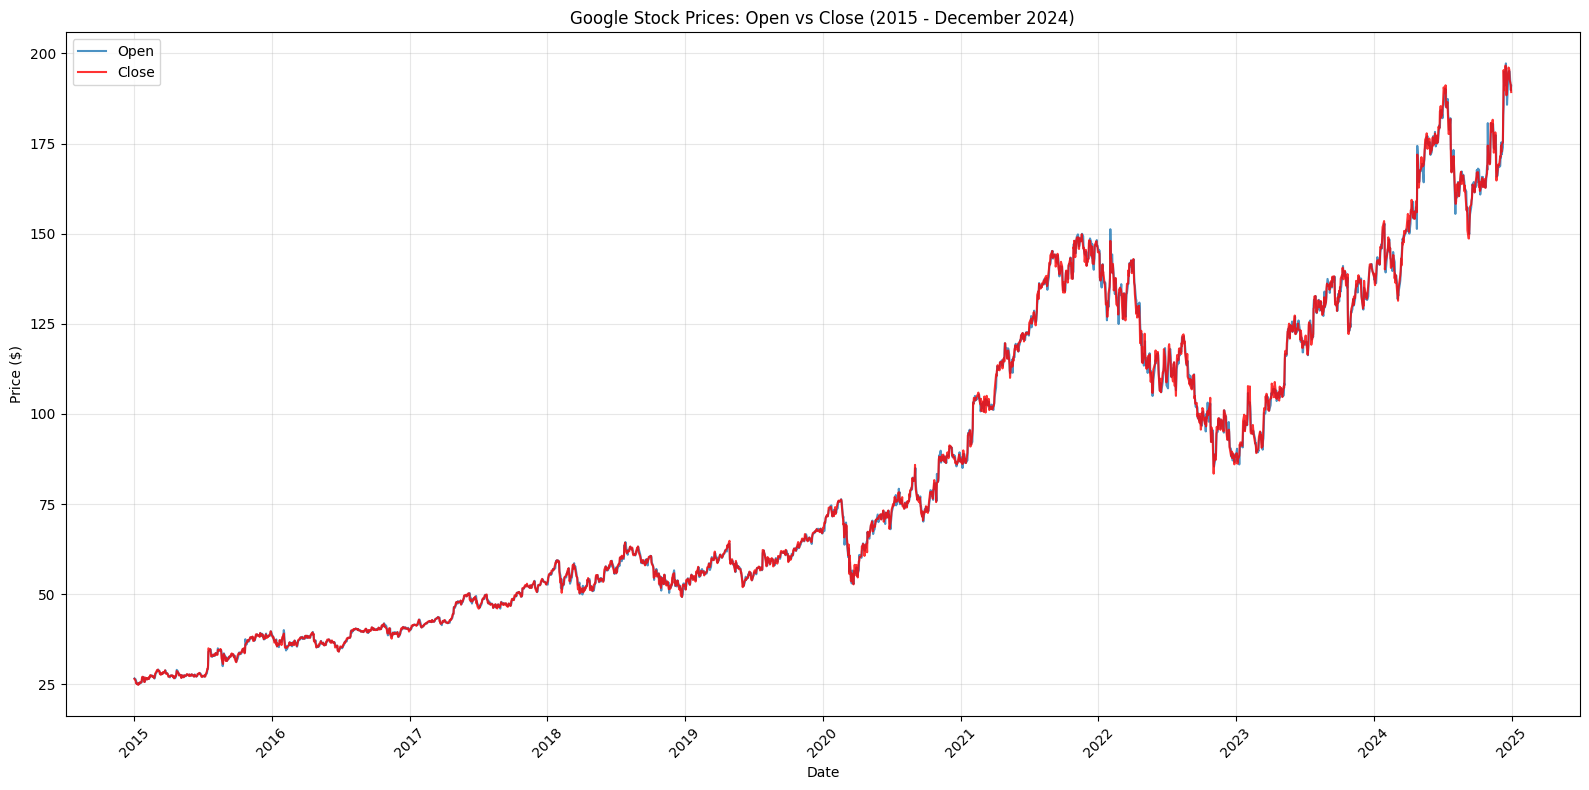

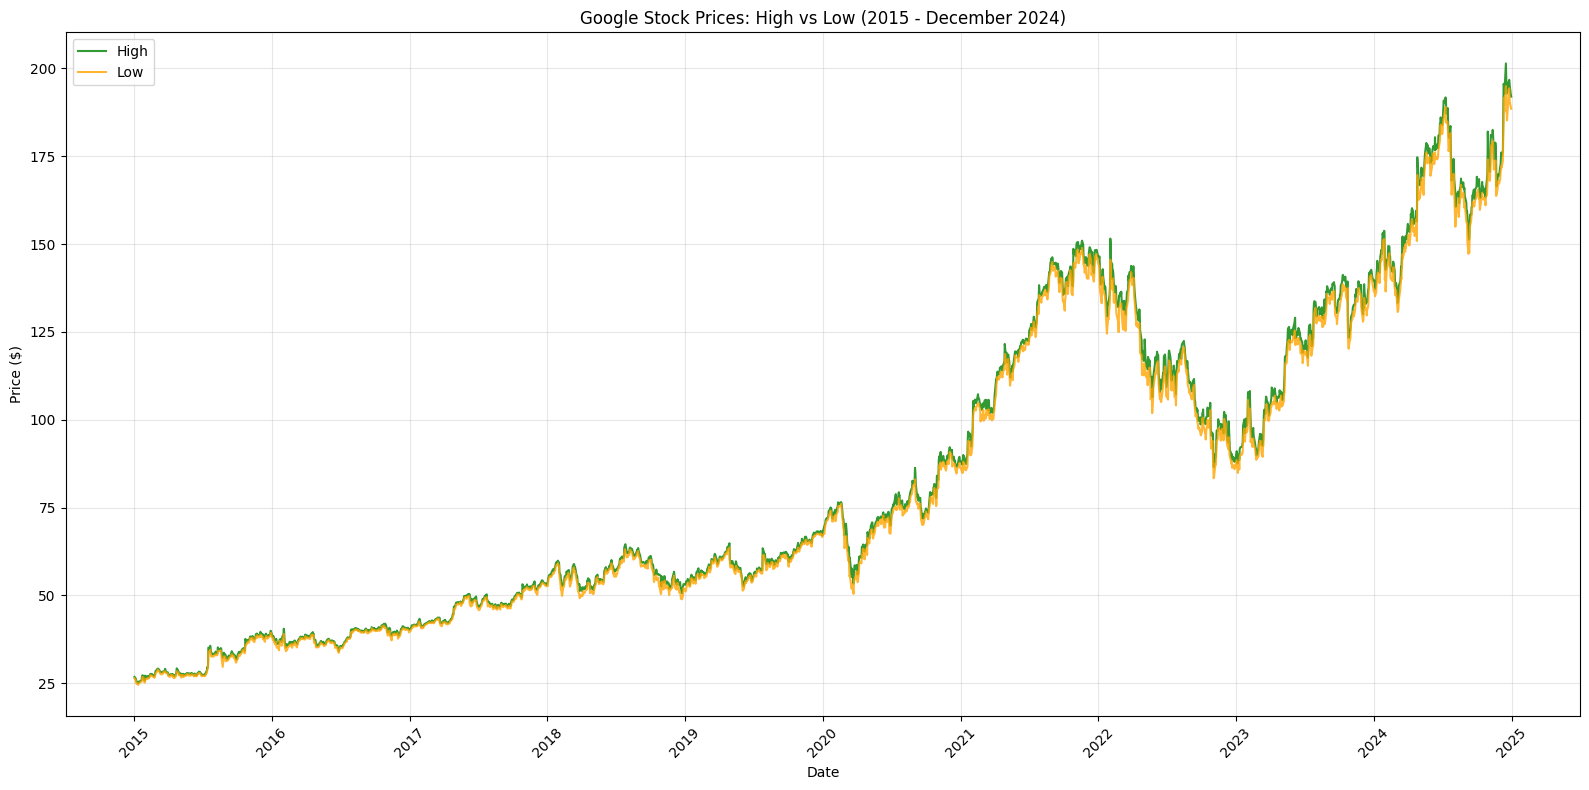

Data available from: 2015-01-02 00:00:00
Data available to: 2024-12-31 00:00:00
Total data points up to Dec 2024: 2516


In [95]:
# Filter data up to December 2024
df_2024 = df[df['Date'] <= '2024-12-31']

# Plot the complete time series from 2015 to December 2024
plt.figure(figsize=(16, 8))
plt.plot(df_2024['Date'], df_2024['Open'], label='Open', alpha=0.8)
plt.plot(df_2024['Date'], df_2024['Close'], label='Close', color='red', alpha=0.8)
plt.title('Google Stock Prices: Open vs Close (2015 - December 2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show High vs Low for the same period
plt.figure(figsize=(16, 8))
plt.plot(df_2024['Date'], df_2024['High'], label='High', color='green', alpha=0.8)
plt.plot(df_2024['Date'], df_2024['Low'], label='Low', color='orange', alpha=0.8)
plt.title('Google Stock Prices: High vs Low (2015 - December 2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check the actual date range
print(f"Data available from: {df['Date'].min()}")
print(f"Data available to: {df['Date'].max()}")
print(f"Total data points up to Dec 2024: {len(df_2024)}")